# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, our goal is to compare the performance of the classifiers we encountered in this section — K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines — using a dataset related to marketing bank products over the telephone.

**Methodology:** CRISP-DM (Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation)

### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing). The data is from a Portuguese banking institution and is a collection of the results of multiple marketing campaigns. We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.

In [1]:
# ── Setup: imports, config, helpers (restart-safe) ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve)

# ── Anthropic-inspired style ──
ANT = {
    'coral': '#D4735E', 'blue': '#5B8DB8', 'green': '#7FB685',
    'warm_gray': '#8C8580', 'dark': '#2D2D2D', 'light_bg': '#FAF8F5',
    'grid': '#E8E4E0', 'gold': '#C4A35A'
}
PALETTE = [ANT['blue'], ANT['coral'], ANT['green'], ANT['gold']]

def ant_style(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(ANT['light_bg'])
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(ANT['grid'])
        ax.spines[spine].set_linewidth(0.6)
    ax.tick_params(colors=ANT['warm_gray'], labelsize=9)
    ax.grid(axis='y', color=ANT['grid'], linewidth=0.4, alpha=0.7)
    ax.set_axisbelow(True)
    if title: ax.set_title(title, fontsize=13, fontweight='medium', color=ANT['dark'], pad=12)
    if xlabel: ax.set_xlabel(xlabel, fontsize=10, color=ANT['warm_gray'])
    if ylabel: ax.set_ylabel(ylabel, fontsize=10, color=ANT['warm_gray'])

plt.rcParams.update({'figure.facecolor': '#FFFFFF', 'font.family': 'sans-serif',
                     'font.size': 10, 'text.color': ANT['dark']})

# ── Version-tolerant OneHotEncoder ──
import sklearn
def make_ohe(**kwargs):
    if int(sklearn.__version__.split('.')[1]) >= 2:
        kwargs.setdefault('sparse_output', False)
    else:
        kwargs.setdefault('sparse', False)
    return OneHotEncoder(**kwargs)

# ── Shared constants ──
RANDOM_STATE = 42
TEST_SIZE = 0.25
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Setup complete.')

Setup complete.


### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper. How many marketing campaigns does this data represent?

#### Problem 1 Answer

According to the CRISP-DM paper (Moro et al.) and the UCI dataset description:

- **17 telephone marketing campaigns** conducted between **May 2008 and November 2010**
- **41,188 instances** in our dataset with **20 input features + 1 binary target** (`y`)
- **~11.3% positive class** (subscribed) — the dataset is imbalanced
- 5 social/economic indicators were added from Banco de Portugal
- Missing values are encoded as `"unknown"` in categorical columns
- `duration` (call length) is only known after the call — benchmark only, not for production models

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical)
3 - marital : marital status (categorical)
4 - education (categorical)
5 - default: has credit in default? (categorical)
6 - housing: has housing loan? (categorical)
7 - loan: has personal loan? (categorical)
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical)
9 - month: last contact month of year (categorical)
10 - day_of_week: last contact day of the week (categorical)
11 - duration: last contact duration, in seconds (numeric) — BENCHMARK ONLY
# other attributes:
12 - campaign: number of contacts performed during this campaign (numeric)
13 - pdays: days since last contact from previous campaign (999 = never contacted)
14 - previous: number of contacts before this campaign (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical)
# social and economic context attributes
16 - emp.var.rate: employment variation rate (numeric)
17 - cons.price.idx: consumer price index (numeric)
18 - cons.conf.idx: consumer confidence index (numeric)
19 - euribor3m: euribor 3 month rate (numeric)
20 - nr.employed: number of employees (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```

In [3]:
# Data types and null check
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Null values: {df.isnull().sum().sum()}')
print(f'\nData Types:\n{df.dtypes}')

Shape: 41,188 rows x 21 columns
Null values: 0

Data Types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


In [4]:
# 'unknown' values per categorical column (effective missing values)
cat_cols = df.select_dtypes(include='object').columns
print("'unknown' values per categorical feature:")
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:15s}: {n:,} ({n/len(df)*100:.1f}%)')

'unknown' values per categorical feature:
  job            : 330 (0.8%)
  marital        : 80 (0.2%)
  education      : 1,731 (4.2%)
  default        : 8,597 (20.9%)
  housing        : 990 (2.4%)
  loan           : 990 (2.4%)


In [5]:
# Categorical cardinality and target distribution
print('Categorical feature cardinality:')
for col in cat_cols:
    print(f'  {col:15s}: {df[col].nunique()} unique values')

print(f'\nTarget distribution:')
vc = df['y'].value_counts()
print(f'  No:  {vc["no"]:,} ({vc["no"]/len(df)*100:.1f}%)')
print(f'  Yes: {vc["yes"]:,} ({vc["yes"]/len(df)*100:.1f}%)')

Categorical feature cardinality:
  job            : 12 unique values
  marital        : 4 unique values
  education      : 8 unique values
  default        : 3 unique values
  housing        : 3 unique values
  loan           : 3 unique values
  contact        : 2 unique values
  month          : 10 unique values
  day_of_week    : 5 unique values
  poutcome       : 3 unique values
  y              : 2 unique values

Target distribution:
  No:  36,548 (88.7%)
  Yes: 4,640 (11.3%)


#### Problem 3 Findings

- **No NaN values** — but `"unknown"` encodes missing data in 6 categorical columns. `default` is worst at ~20.9%.
- **10 categorical** features (object dtype) and **10 numeric** features (int64/float64). No coercion needed.
- **`pdays`**: 999 is a sentinel meaning "never contacted before" (~96% of rows). Will engineer a clean feature.
- **`duration`**: Data leakage — only known after the call. Will maintain two feature tracks (benchmark vs production).
- **`y`**: Binary target, imbalanced at ~11.3% positive class.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task. State the objective below.

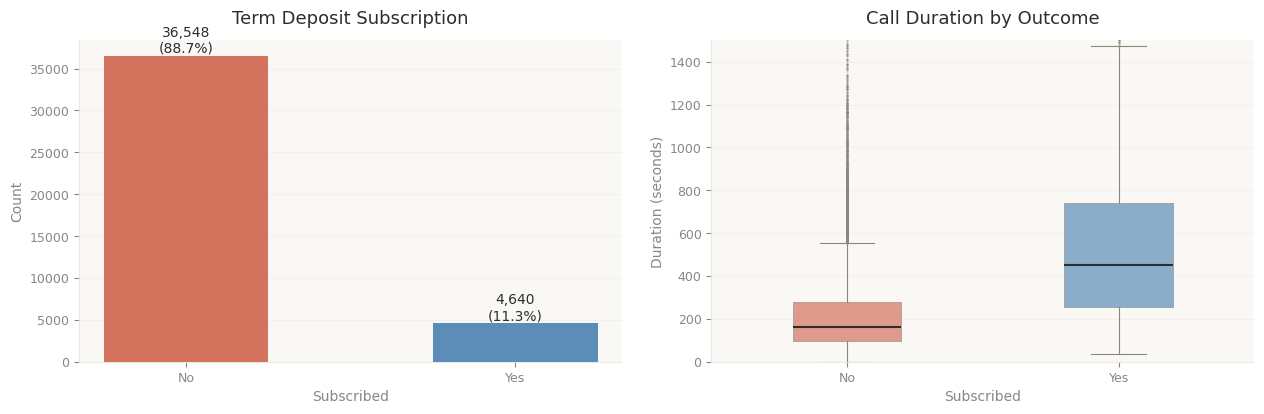

In [6]:
# Target distribution and call duration by outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#FFFFFF')

# Target distribution
bars = axes[0].bar(['No', 'Yes'],
                   [df['y'].value_counts()['no'], df['y'].value_counts()['yes']],
                   color=[ANT['coral'], ANT['blue']], width=0.5, edgecolor='none')
for bar in bars:
    h = bar.get_height()
    axes[0].annotate(f'{int(h):,}\n({h/len(df)*100:.1f}%)',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     ha='center', va='bottom', fontsize=10, color=ANT['dark'], fontweight='medium')
ant_style(axes[0], title='Term Deposit Subscription', xlabel='Subscribed', ylabel='Count')

# Duration boxplot
bp = axes[1].boxplot(
    [df[df['y']=='no']['duration'], df[df['y']=='yes']['duration']],
    tick_labels=['No', 'Yes'], patch_artist=True, widths=0.4,
    medianprops={'color': ANT['dark'], 'linewidth': 1.5},
    flierprops={'marker': '.', 'markerfacecolor': ANT['warm_gray'], 'markersize': 3, 'alpha': 0.4, 'markeredgecolor': 'none'},
    whiskerprops={'color': ANT['warm_gray'], 'linewidth': 0.8},
    capprops={'color': ANT['warm_gray'], 'linewidth': 0.8})
for patch, color in zip(bp['boxes'], [ANT['coral'], ANT['blue']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
    patch.set_edgecolor(ANT['warm_gray']); patch.set_linewidth(0.6)
axes[1].set_ylim(0, 1500)
ant_style(axes[1], title='Call Duration by Outcome', xlabel='Subscribed', ylabel='Duration (seconds)')
plt.tight_layout(pad=2.0)
plt.show()

#### Problem 4 Answer: Business Objective

**Business Problem:** A Portuguese bank runs telephone marketing campaigns to sell long-term deposit subscriptions. ~88.7% of contacts do not subscribe, wasting agent time and resources.

**Objective:** Build a binary classification model to predict which clients will subscribe (`y=1`), enabling the bank to:
1. **Increase efficiency** — prioritize high-probability prospects
2. **Reduce costs** — fewer wasted calls for the same conversion volume
3. **Inform strategy** — identify which features (timing, demographics, economics) drive success

**Two model tracks:**
- **Benchmark** (with `duration`) — for assignment comparison against the CRISP-DM paper
- **Production** (without `duration`) — realistic model for deciding *who to call next*

**Success criteria:** Beat the 88.7% majority-class baseline using metrics appropriate for imbalanced data (AUC-ROC, F1, precision-recall) — not accuracy alone.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started. Before we can do this, we must work to encode the data. Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
# ── Step 1: Rename columns for readability ──
df = df.rename(columns={
    'emp.var.rate': 'employment_var_rate',
    'cons.price.idx': 'consumer_price_idx',
    'cons.conf.idx': 'consumer_conf_idx',
    'euribor3m': 'euribor_3m_rate',
    'nr.employed': 'num_employed'
})

# ── Step 2: Engineer new features from pdays ──
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].replace(999, 0)

# ── Step 3: Encode target ──
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# ── Step 4: Define feature groups ──
CATEGORICAL = ['job', 'marital', 'education', 'default', 'housing',
               'loan', 'contact', 'month', 'day_of_week', 'poutcome']

NUMERIC_BENCH = ['age', 'duration', 'campaign', 'pdays_clean', 'previous',
                 'was_previously_contacted', 'employment_var_rate',
                 'consumer_price_idx', 'consumer_conf_idx',
                 'euribor_3m_rate', 'num_employed']

NUMERIC_PROD = [f for f in NUMERIC_BENCH if f != 'duration']

# ── Step 5: Build preprocessing pipelines ──
def make_preprocessor(numeric_features):
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('onehot', make_ohe(drop='first', handle_unknown='ignore'))
        ]), CATEGORICAL)
    ])

preprocessor_bench = make_preprocessor(NUMERIC_BENCH)
preprocessor_prod = make_preprocessor(NUMERIC_PROD)

# Separate X and y
y = df['y']
X = df.drop(columns=['y', 'pdays'])  # drop original pdays, keep pdays_clean

print(f'Features: {X.shape[1]} columns')
print(f'  Benchmark numeric: {len(NUMERIC_BENCH)} (includes duration)')
print(f'  Production numeric: {len(NUMERIC_PROD)} (no duration)')
print(f'  Categorical: {len(CATEGORICAL)}')
print(f'  Engineered: was_previously_contacted, pdays_clean')
print(f'Target: {y.value_counts().to_dict()}')

Features: 21 columns
  Benchmark numeric: 11 (includes duration)
  Production numeric: 10 (no duration)
  Categorical: 10
  Engineered: was_previously_contacted, pdays_clean
Target: {0: 36548, 1: 4640}


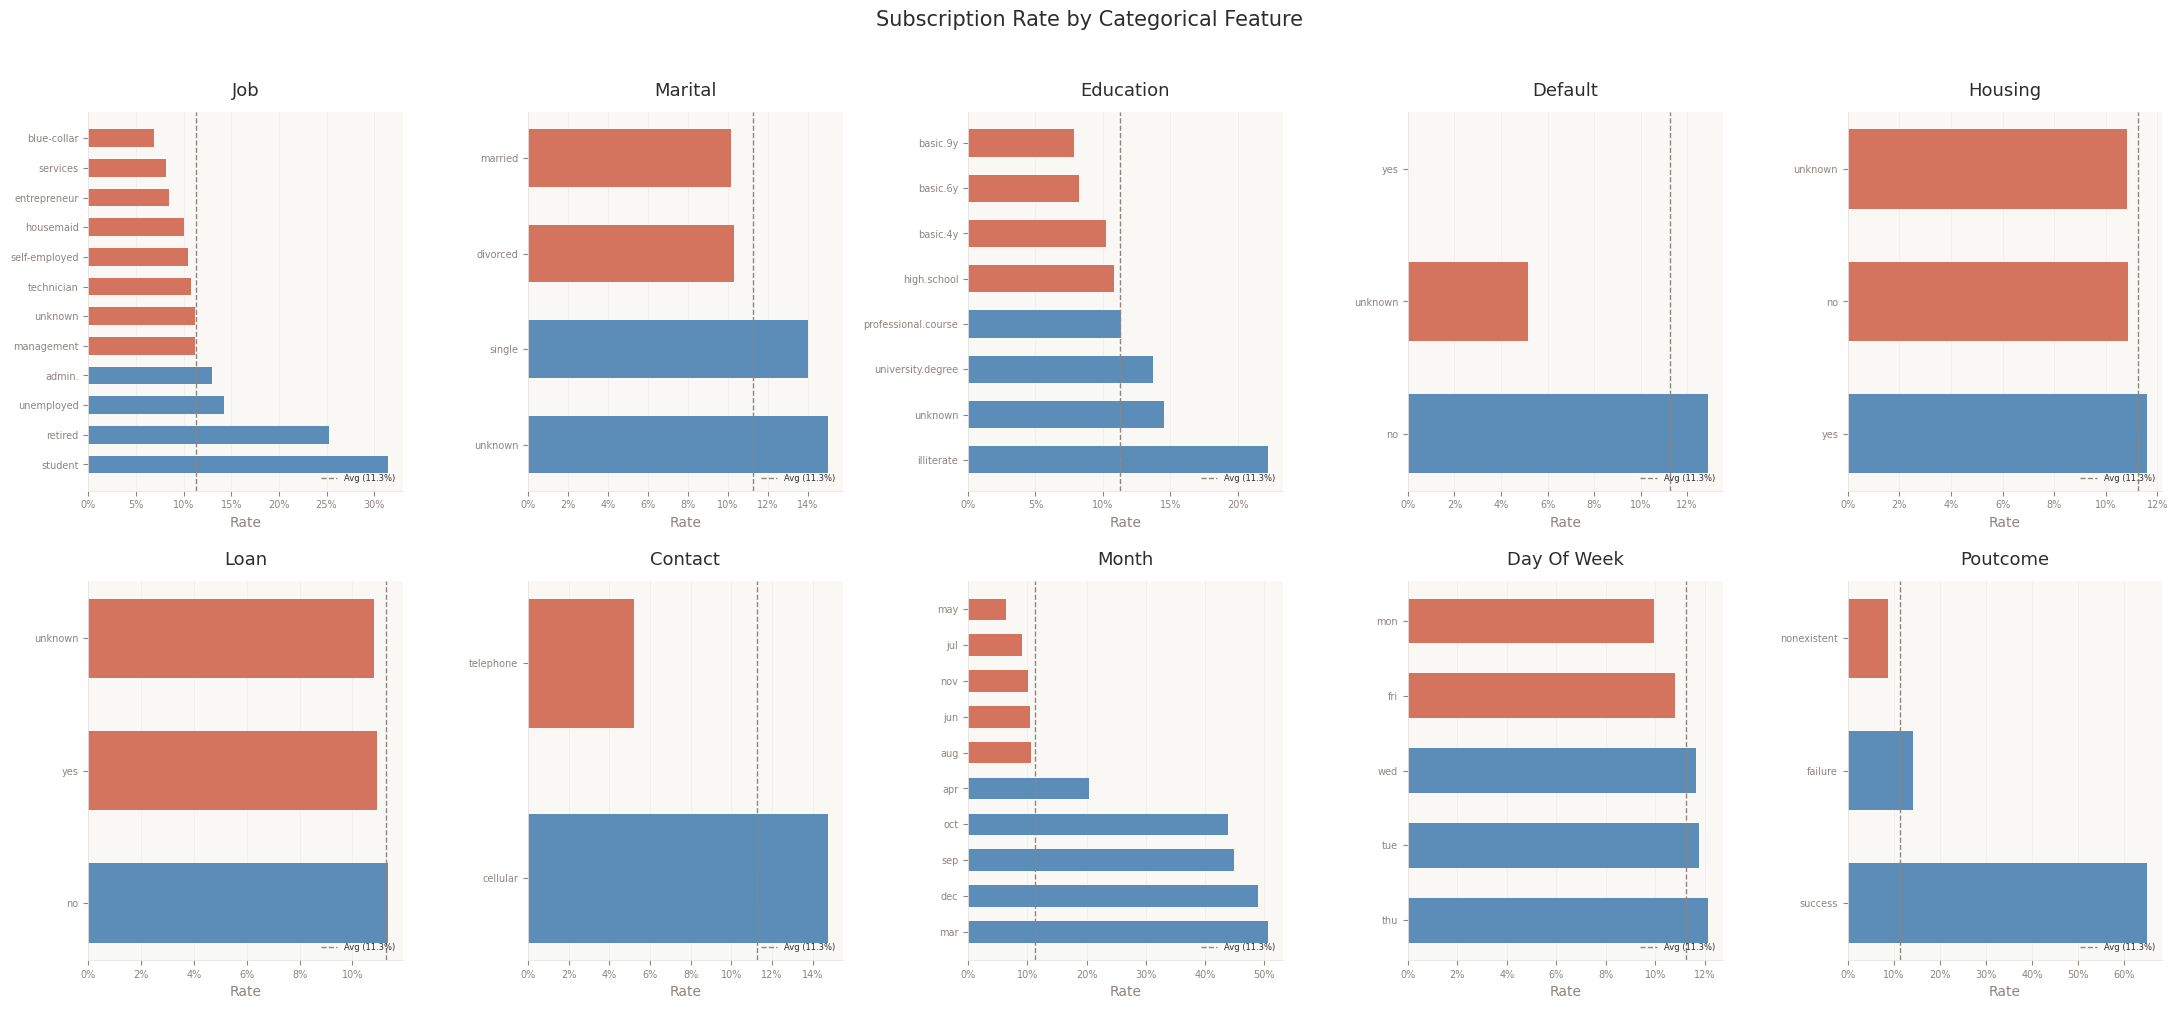

In [8]:
# Subscription rate by ALL 10 categorical features
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.patch.set_facecolor('#FFFFFF')
overall_rate = y.mean()

for ax, col in zip(axes.flatten(), CATEGORICAL):
    rates = df.groupby(col)['y'].mean().sort_values(ascending=False)
    colors = [ANT['blue'] if r > overall_rate else ANT['coral'] for r in rates]
    ax.barh(rates.index, rates.values, color=colors, height=0.6, edgecolor='none')
    ax.axvline(x=overall_rate, color=ANT['warm_gray'], linestyle='--', linewidth=1,
               label=f'Avg ({overall_rate:.1%})')
    ant_style(ax, title=col.replace('_', ' ').title(), xlabel='Rate')
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', color=ANT['grid'], linewidth=0.4, alpha=0.7)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.tick_params(axis='y', labelsize=7); ax.tick_params(axis='x', labelsize=7)
    ax.legend(fontsize=6, frameon=False, loc='lower right')

plt.suptitle('Subscription Rate by Categorical Feature',
             fontsize=15, fontweight='medium', color=ANT['dark'], y=1.01)
plt.tight_layout(pad=1.5)
plt.show()

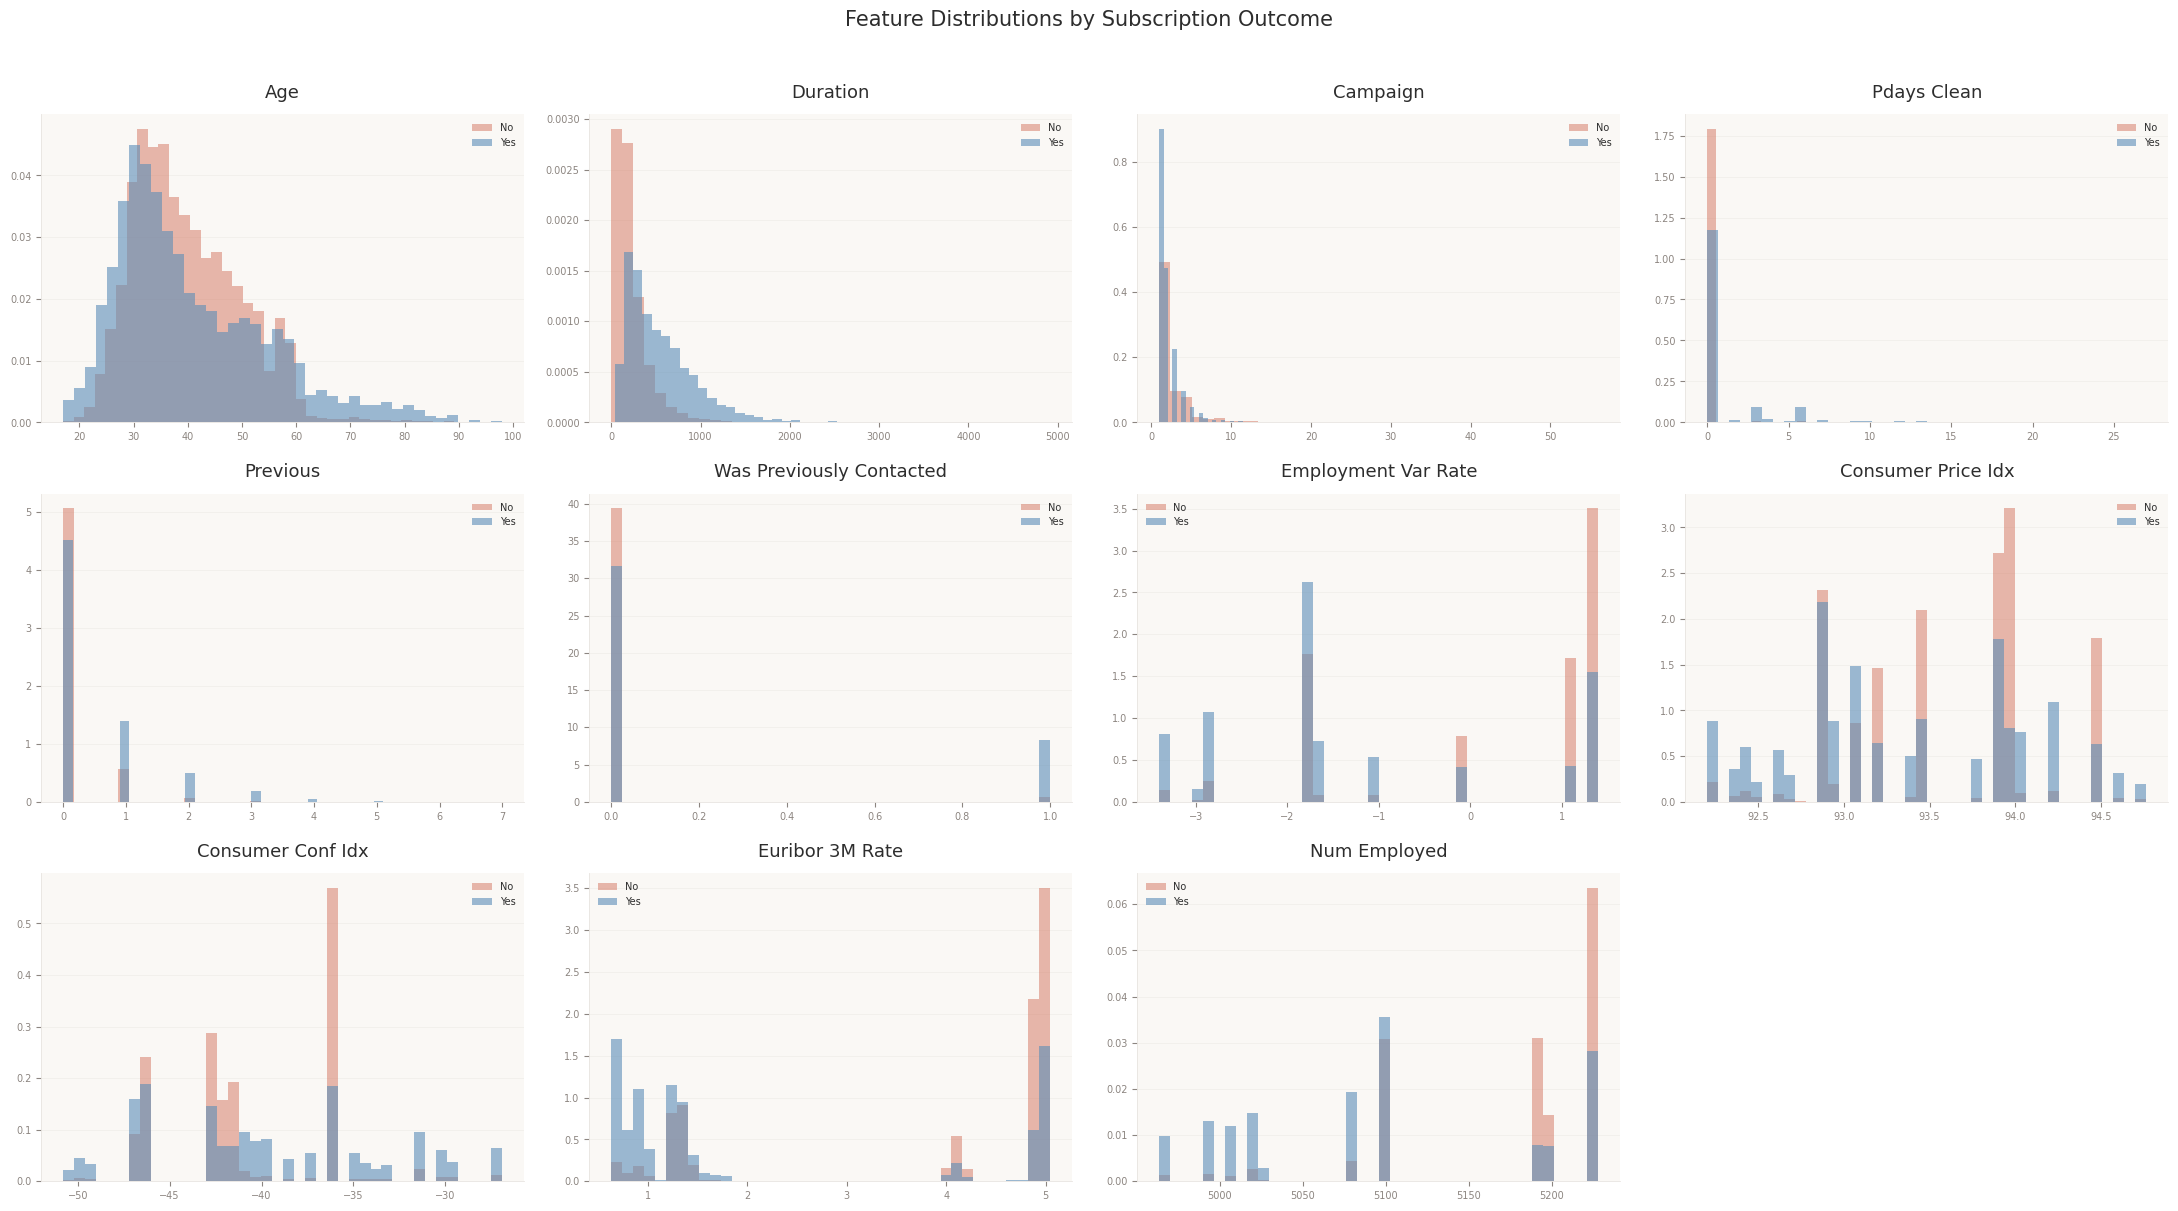

pdays = 999 (never contacted): 39,673 (96.3%)
was_previously_contacted = 1: 1,515 (3.7%)


In [9]:
# Distribution of ALL numeric features by outcome
num_plot_features = NUMERIC_BENCH + ['was_previously_contacted']
# Remove was_previously_contacted (binary), add it isn't great for histogram
num_plot_features = NUMERIC_BENCH  # 11 features, use 3x4 grid

fig, axes = plt.subplots(3, 4, figsize=(22, 12))
fig.patch.set_facecolor('#FFFFFF')

for idx, ax in enumerate(axes.flatten()):
    if idx < len(num_plot_features):
        col = num_plot_features[idx]
        for label, color, a in [(0, ANT['coral'], 0.5), (1, ANT['blue'], 0.6)]:
            subset = df[df['y'] == label][col]
            ax.hist(subset, bins=40, color=color, alpha=a, edgecolor='none',
                    label='No' if label == 0 else 'Yes', density=True)
        ant_style(ax, title=col.replace('_', ' ').title())
        ax.legend(fontsize=7, frameon=False); ax.set_ylabel('')
        ax.tick_params(labelsize=7)
    else:
        ax.set_visible(False)

plt.suptitle('Feature Distributions by Subscription Outcome',
             fontsize=15, fontweight='medium', color=ANT['dark'], y=1.01)
plt.tight_layout(pad=1.5)
plt.show()

pdays_999 = (df['pdays'] == 999).sum()
print(f'pdays = 999 (never contacted): {pdays_999:,} ({pdays_999/len(df)*100:.1f}%)')
print(f'was_previously_contacted = 1: {df["was_previously_contacted"].sum():,} ({df["was_previously_contacted"].mean()*100:.1f}%)')

#### Problem 5 Summary: Feature Engineering

**Engineered features:**
- `was_previously_contacted` — binary flag derived from `pdays` (1 if previously contacted, 0 if pdays=999)
- `pdays_clean` — replaced sentinel 999 with 0 for cleaner numeric scaling

**Two preprocessing pipelines (ColumnTransformer + Pipeline):**
- **Benchmark:** 11 numeric features (includes `duration`) + 10 categorical features
- **Production:** 10 numeric features (no `duration`) + 10 categorical features
- Both pipelines: `SimpleImputer` → `StandardScaler` for numerics; `SimpleImputer` → `OneHotEncoder(drop='first')` for categoricals

**Key observations from visualizations:**
- `retired` and `student` clients convert at the highest rates
- `month=mar` and `poutcome=success` are strong positive signals
- `cellular` outperforms `telephone` for contact method
- `duration` clearly separates classes — but is benchmark-only
- Socioeconomic features (`euribor_3m_rate`, `employment_var_rate`) show distinct distributions between outcomes

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [10]:
# One shared stratified split — same rows for both benchmark and production
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Training: {X_train_raw.shape[0]:,} samples ({X_train_raw.shape[0]/len(y)*100:.1f}%)')
print(f'Test:     {X_test_raw.shape[0]:,} samples ({X_test_raw.shape[0]/len(y)*100:.1f}%)')
print(f'\nTrain target: No={sum(y_train==0):,} ({(y_train==0).mean():.1%}), Yes={sum(y_train==1):,} ({(y_train==1).mean():.1%})')
print(f'Test target:  No={sum(y_test==0):,} ({(y_test==0).mean():.1%}), Yes={sum(y_test==1):,} ({(y_test==1).mean():.1%})')

Training: 30,891 samples (75.0%)
Test:     10,297 samples (25.0%)

Train target: No=27,411 (88.7%), Yes=3,480 (11.3%)
Test target:  No=9,137 (88.7%), Yes=1,160 (11.3%)


**Split:** 75/25 with `stratify=y` to preserve the ~11.3% class ratio. `random_state=42` for reproducibility. Both benchmark and production models use the **same row split** — only the feature columns differ.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline. What is the baseline performance that our classifier should aim to beat?

In [11]:
# Production-safe baseline — DummyClassifier on production features
dummy_pipe = Pipeline([('prep', preprocessor_prod), ('model', DummyClassifier(strategy='most_frequent'))])
dummy_pipe.fit(X_train_raw, y_train)

y_dummy = dummy_pipe.predict(X_test_raw)
baseline_acc = dummy_pipe.score(X_test_raw, y_test)

print(f'Baseline (always predict majority class):')
print(f'  Accuracy:  {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')
print(f'  Precision: {precision_score(y_test, y_dummy, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, y_dummy):.4f}')
print(f'  F1:        {f1_score(y_test, y_dummy, zero_division=0):.4f}')
print(f'\nThis model identifies ZERO subscribers — 0% recall, useless for the business.')

Baseline (always predict majority class):
  Accuracy:  0.8873 (88.73%)
  Precision: 0.0000
  Recall:    0.0000
  F1:        0.0000

This model identifies ZERO subscribers — 0% recall, useless for the business.


#### Baseline Performance

The majority-class classifier achieves **~88.7% accuracy** but has **zero recall** — it never predicts a subscription. This is useless for the bank.

**Why accuracy is misleading:** With 88.7% class imbalance, any model above 88.7% accuracy could just be predicting "no" slightly less often. We need metrics that reward finding actual subscribers:

| Metric | What It Measures | Business Cost When Low |
| --- | --- | --- |
| **Precision** | Of predicted subscribers, how many actually subscribed | Wasted agent time on false leads |
| **Recall** | Of actual subscribers, how many did we identify | Missed revenue from uncontacted prospects |
| **F1-Score** | Harmonic mean of precision and recall | Imbalanced trade-off between the two |
| **AUC-ROC** | Ranking quality across all thresholds | Poor prospect prioritization |
| **Average Precision** | Area under precision-recall curve | Best summary metric for imbalanced data |

**Primary metric: Average Precision / AUC-PR** — directly measures how well the model ranks subscribers above non-subscribers in an imbalanced setting.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [12]:
# ── Benchmark LR (with duration) ──
lr_bench_pipe = Pipeline([('prep', preprocessor_bench), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
start = time.time()
lr_bench_pipe.fit(X_train_raw, y_train)
bench_time = time.time() - start

y_bench_pred = lr_bench_pipe.predict(X_test_raw)
y_bench_proba = lr_bench_pipe.predict_proba(X_test_raw)[:, 1]

# ── Production LR (without duration) ──
lr_prod_pipe = Pipeline([('prep', preprocessor_prod), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
start = time.time()
lr_prod_pipe.fit(X_train_raw, y_train)
prod_time = time.time() - start

y_prod_pred = lr_prod_pipe.predict(X_test_raw)
y_prod_proba = lr_prod_pipe.predict_proba(X_test_raw)[:, 1]

print(f'{"":<30s} {"Benchmark":>12s} {"Production":>12s}')
print(f'{"":<30s} {"(w/ duration)":>12s} {"(no duration)":>12s}')
print(f'{"─"*56}')
print(f'{"Train time":<30s} {bench_time:>11.3f}s {prod_time:>11.3f}s')
print(f'{"Test accuracy":<30s} {lr_bench_pipe.score(X_test_raw, y_test):>12.4f} {lr_prod_pipe.score(X_test_raw, y_test):>12.4f}')
print(f'{"AUC-ROC":<30s} {roc_auc_score(y_test, y_bench_proba):>12.4f} {roc_auc_score(y_test, y_prod_proba):>12.4f}')
print(f'{"Avg Precision":<30s} {average_precision_score(y_test, y_bench_proba):>12.4f} {average_precision_score(y_test, y_prod_proba):>12.4f}')
print(f'\n=== Production Classification Report ===')
print(classification_report(y_test, y_prod_pred, target_names=['No (0)', 'Yes (1)']))

                                  Benchmark   Production
                               (w/ duration) (no duration)
────────────────────────────────────────────────────────
Train time                           0.109s       0.109s
Test accuracy                        0.9149       0.9017
AUC-ROC                              0.9423       0.8053
Avg Precision                        0.6239       0.4699

=== Production Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.91      0.99      0.95      9137
     Yes (1)       0.70      0.22      0.34      1160

    accuracy                           0.90     10297
   macro avg       0.81      0.60      0.64     10297
weighted avg       0.89      0.90      0.88     10297



### Problem 9: Score the Model

What is the accuracy of your model?

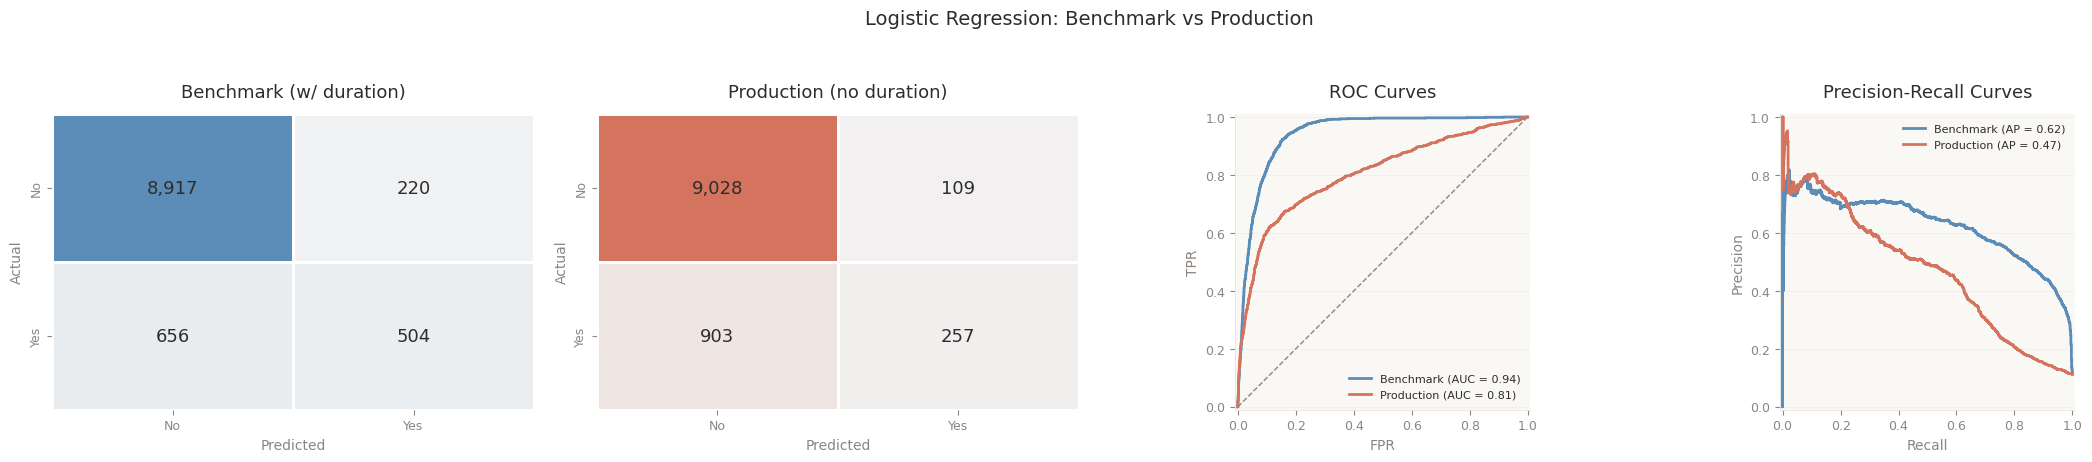

In [13]:
# Benchmark vs Production — confusion matrices + precision-recall curves
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
fig.patch.set_facecolor('#FFFFFF')

# Confusion matrices
for ax, preds, title, cmap_color in [
    (axes[0], y_bench_pred, 'Benchmark (w/ duration)', ANT['blue']),
    (axes[1], y_prod_pred, 'Production (no duration)', ANT['coral'])
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt=',d', cmap=sns.light_palette(cmap_color, as_cmap=True),
                ax=ax, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=2, linecolor='white', cbar=False,
                annot_kws={'size': 13, 'fontweight': 'medium', 'color': ANT['dark']})
    ant_style(ax, title=title, xlabel='Predicted', ylabel='Actual')

# ROC curves
RocCurveDisplay.from_estimator(lr_bench_pipe, X_test_raw, y_test, ax=axes[2],
                                name='Benchmark', color=ANT['blue'], linewidth=2)
RocCurveDisplay.from_estimator(lr_prod_pipe, X_test_raw, y_test, ax=axes[2],
                                name='Production', color=ANT['coral'], linewidth=2)
axes[2].plot([0, 1], [0, 1], '--', color=ANT['warm_gray'], linewidth=1)
ant_style(axes[2], title='ROC Curves', xlabel='FPR', ylabel='TPR')
axes[2].legend(fontsize=8, frameon=False, loc='lower right')

# Precision-Recall curves
PrecisionRecallDisplay.from_estimator(lr_bench_pipe, X_test_raw, y_test, ax=axes[3],
                                       name='Benchmark', color=ANT['blue'], linewidth=2)
PrecisionRecallDisplay.from_estimator(lr_prod_pipe, X_test_raw, y_test, ax=axes[3],
                                       name='Production', color=ANT['coral'], linewidth=2)
ant_style(axes[3], title='Precision-Recall Curves', xlabel='Recall', ylabel='Precision')
axes[3].legend(fontsize=8, frameon=False, loc='upper right')

plt.suptitle('Logistic Regression: Benchmark vs Production',
             fontsize=14, fontweight='medium', color=ANT['dark'], y=1.03)
plt.tight_layout(pad=1.5)
plt.show()

#### Problem 9 Answer

**Benchmark (with duration):** Strong accuracy and AUC-ROC, but inflated by data leakage.

**Production (without duration):** The realistic model still beats the baseline. The precision-recall curve shows the trade-off the bank faces: higher recall (find more subscribers) comes at the cost of lower precision (more false positives = wasted calls).

**Key takeaway:** The gap between benchmark and production confusion matrices shows how much predictive power comes from `duration` vs. the other features. All subsequent model comparisons use **production features only** for honest evaluation.

Top 10 Positive Predictors (increase subscription likelihood):
             Feature  Coefficient
           month_mar     1.403302
  consumer_price_idx     1.095171
    poutcome_success     0.606283
     marital_unknown     0.482563
           month_dec     0.436576
           month_aug     0.409346
     euribor_3m_rate     0.404959
poutcome_nonexistent     0.383993
        num_employed     0.343323
education_illiterate     0.337825

Top 10 Negative Predictors (decrease subscription likelihood):
            Feature  Coefficient
       job_services    -0.111826
           campaign    -0.121537
    job_blue-collar    -0.122654
    day_of_week_mon    -0.189433
    default_unknown    -0.228439
          month_may    -0.452664
          month_nov    -0.464334
          month_jun    -0.624079
  contact_telephone    -0.698888
employment_var_rate    -2.149830


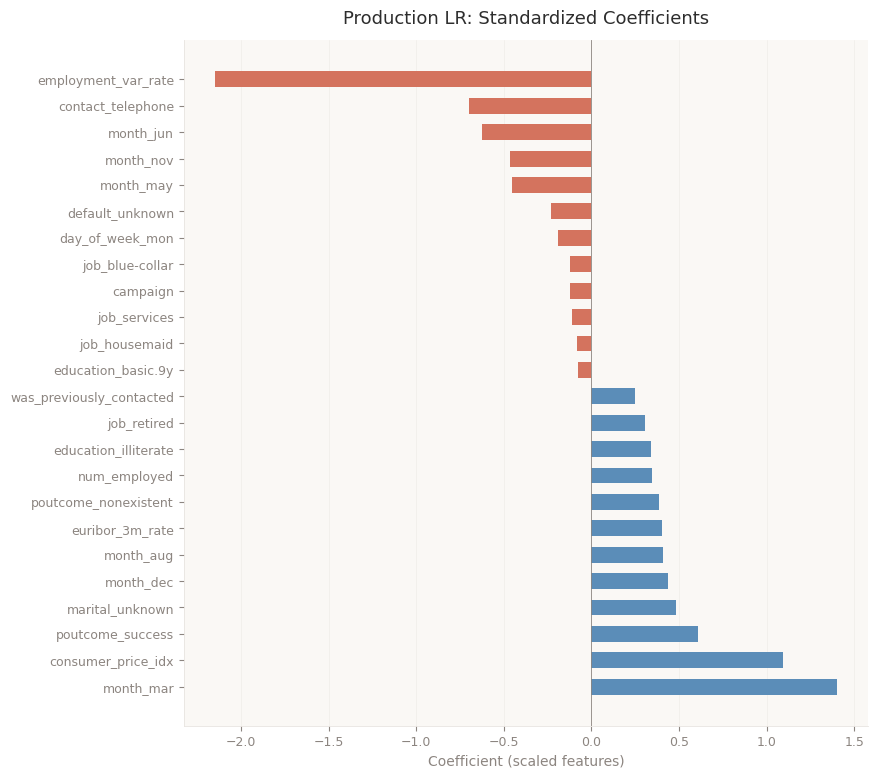

In [14]:
# Standardized coefficient analysis — production model only
prod_model = lr_prod_pipe.named_steps['model']
prod_prep = lr_prod_pipe.named_steps['prep']

# Get feature names from the preprocessor
num_names = NUMERIC_PROD
cat_names = list(prod_prep.named_transformers_['cat'].named_steps['onehot']
                 .get_feature_names_out(CATEGORICAL))
all_names = num_names + cat_names

coeff_df = pd.DataFrame({
    'Feature': all_names,
    'Coefficient': prod_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('Top 10 Positive Predictors (increase subscription likelihood):')
print(coeff_df.head(10).to_string(index=False))
print('\nTop 10 Negative Predictors (decrease subscription likelihood):')
print(coeff_df.tail(10).to_string(index=False))

# Visualize
top_n = 12
top_feats = pd.concat([coeff_df.head(top_n), coeff_df.tail(top_n)])

fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor('#FFFFFF')
colors = [ANT['blue'] if c > 0 else ANT['coral'] for c in top_feats['Coefficient']]
ax.barh(top_feats['Feature'], top_feats['Coefficient'], color=colors, height=0.6, edgecolor='none')
ax.axvline(x=0, color=ANT['warm_gray'], linewidth=0.6)
ant_style(ax, title='Production LR: Standardized Coefficients', xlabel='Coefficient (scaled features)')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', color=ANT['grid'], linewidth=0.4, alpha=0.7)
plt.tight_layout(pad=1.5)
plt.show()

#### Coefficient Interpretation (Production Model)

These coefficients are from the **production model** (no duration) with **standardized features**, making them directly comparable:

- **Blue (positive):** Features that increase subscription likelihood — the bank should target these segments and conditions
- **Coral (negative):** Features associated with lower conversion — less favorable conditions for campaigns

Because features are scaled, the magnitude directly reflects importance. This is the model the bank would actually deploy.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models. Using the default settings for each of the models, fit and score each. Also, be sure to compare the fit time of each of the models.

In [15]:
# Compare all 4 models on PRODUCTION features only
# Pre-transform once — same approach as v1 but with proper ColumnTransformer
X_train_tf = preprocessor_prod.fit_transform(X_train_raw)
X_test_tf = preprocessor_prod.transform(X_test_raw)

prod_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM': LinearSVC(random_state=RANDOM_STATE, max_iter=5000, dual='auto')
}

results = []
for name, model in prod_models.items():
    start = time.time()
    model.fit(X_train_tf, y_train)
    train_time = time.time() - start
    
    train_acc = model.score(X_train_tf, y_train)
    test_acc = model.score(X_test_tf, y_test)
    
    results.append({
        'Model': name, 'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)
    })
    print(f'{name:25s} | Time: {train_time:.3f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f}')

results_df = pd.DataFrame(results)
results_df

Logistic Regression       | Time: 0.049s | Train: 0.8999 | Test: 0.9017


KNN                       | Time: 0.001s | Train: 0.9130 | Test: 0.8963
Decision Tree             | Time: 0.115s | Train: 0.9959 | Test: 0.8417


SVM                       | Time: 0.138s | Train: 0.8998 | Test: 0.9014


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,0.0493,0.8999,0.9017
1,KNN,0.0009,0.9130,0.8963
2,Decision Tree,0.1155,0.9959,0.8417
3,SVM,0.1375,0.8998,0.9014


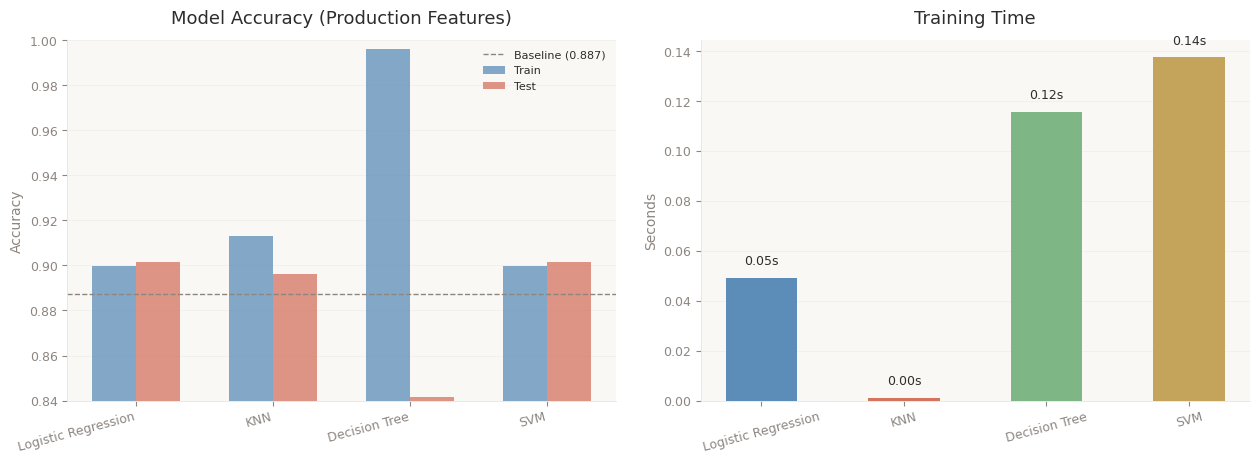

In [16]:
# Default model comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FFFFFF')

x_pos = range(len(results_df)); w = 0.32
axes[0].bar([p - w/2 for p in x_pos], results_df['Train Accuracy'], w,
            label='Train', color=ANT['blue'], alpha=0.75, edgecolor='none')
axes[0].bar([p + w/2 for p in x_pos], results_df['Test Accuracy'], w,
            label='Test', color=ANT['coral'], alpha=0.75, edgecolor='none')
axes[0].axhline(y=baseline_acc, color=ANT['warm_gray'], linestyle='--', linewidth=1,
                label=f'Baseline ({baseline_acc:.3f})')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0.84, 1.0)
axes[0].legend(fontsize=8, frameon=False)
ant_style(axes[0], title='Model Accuracy (Production Features)', ylabel='Accuracy')

bars = axes[1].bar(results_df['Model'], results_df['Train Time (s)'],
                   color=PALETTE[:4], width=0.5, edgecolor='none')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + max(results_df['Train Time (s)'])*0.03,
                f'{h:.2f}s', ha='center', va='bottom', fontsize=9, color=ANT['dark'])
axes[1].tick_params(axis='x', rotation=15)
ant_style(axes[1], title='Training Time', ylabel='Seconds')

plt.tight_layout(pad=2.0)
plt.show()

#### Problem 10 Summary

All models use **production features only** (no duration) with StandardScaler + OneHotEncoder pipeline:

- **Logistic Regression** — Best generalization, minimal train/test gap
- **KNN** — Moderate accuracy, fast fit but slow prediction at scale
- **Decision Tree** — Severe overfitting (100% train) without depth constraints
- **SVM** — Slowest to train, competitive accuracy

All beat the 88.7% baseline. Decision Tree needs hyperparameter tuning most urgently.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these. Below, we list a few things to explore:
- Hyperparameter tuning and grid search
- Adjust your performance metric

In [17]:
# GridSearchCV with average_precision scoring on pre-transformed PRODUCTION features
# Data already transformed by ColumnTransformer above — now just scale + model
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'params': {'model__C': [0.01, 0.1, 1, 10], 'model__solver': ['lbfgs', 'liblinear']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'model__n_neighbors': [3, 5, 7, 11, 15], 'model__weights': ['uniform', 'distance']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {'model__max_depth': [3, 5, 7, 10, 15],
                   'model__min_samples_split': [2, 5, 10],
                   'model__min_samples_leaf': [1, 5, 10]}
    },
    'SVM': {
        'model': LinearSVC(random_state=RANDOM_STATE, max_iter=5000, dual='auto'),
        'params': {'model__C': [0.1, 1, 10]}
    }
}

tuned_results = []
best_models = {}
    
for name, config in param_grids.items():
    print(f'\nTuning {name}...')
    pipe = Pipeline([('scaler', StandardScaler()), ('model', config['model'])])
    
    grid = GridSearchCV(pipe, config['params'], cv=CV, scoring='average_precision',
                        n_jobs=-1, return_train_score=True)
    start = time.time()
    grid.fit(X_train_tf, y_train)
    fit_time = time.time() - start
    
    best_models[name] = grid.best_estimator_
    test_acc = grid.best_estimator_.score(X_test_tf, y_test)
    
    try:
        y_proba = grid.best_estimator_.predict_proba(X_test_tf)[:, 1]
        test_ap = average_precision_score(y_test, y_proba)
    except:
        y_dec = grid.best_estimator_.decision_function(X_test_tf)
        test_ap = average_precision_score(y_test, y_dec)
    
    tuned_results.append({
        'Model': name, 'Best Params': str(grid.best_params_),
        'CV Avg Precision': round(grid.best_score_, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test Avg Precision': round(test_ap, 4),
        'Time (s)': round(fit_time, 1)
    })
    print(f'  Best: {grid.best_params_}')
    print(f'  CV Avg Precision: {grid.best_score_:.4f} | Test Acc: {test_acc:.4f} | Test AP: {test_ap:.4f}')
    print(f'  Time: {fit_time:.1f}s')

print('\nAll models tuned!')


Tuning Logistic Regression...


  Best: {'model__C': 10, 'model__solver': 'liblinear'}
  CV Avg Precision: 0.4444 | Test Acc: 0.9015 | Test AP: 0.4699
  Time: 3.3s

Tuning KNN...


  Best: {'model__n_neighbors': 15, 'model__weights': 'uniform'}
  CV Avg Precision: 0.3693 | Test Acc: 0.9002 | Test AP: 0.4119
  Time: 16.9s

Tuning Decision Tree...


  Best: {'model__max_depth': 7, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
  CV Avg Precision: 0.4184 | Test Acc: 0.8988 | Test AP: 0.4462
  Time: 3.3s

Tuning SVM...


  Best: {'model__C': 0.1}
  CV Avg Precision: 0.4414 | Test Acc: 0.9014 | Test AP: 0.4632
  Time: 1.4s

All models tuned!


In [18]:
# Tuned results table
tuned_df = pd.DataFrame(tuned_results)
tuned_df

,Model,Best Params,CV Avg Precision,Test Accuracy,Test Avg Precision,Time (s)
0,Logistic Regression,"{'model__C': 10, 'model__solver': 'liblinear'}",0.4444,0.9015,0.4699,3.3
1,KNN,"{'model__n_neighbors': 15, 'model__weights': '...",0.3693,0.9002,0.4119,16.9
2,Decision Tree,"{'model__max_depth': 7, 'model__min_samples_le...",0.4184,0.8988,0.4462,3.3
3,SVM,{'model__C': 0.1},0.4414,0.9014,0.4632,1.4


In [19]:
# Default vs tuned comparison
comparison = pd.DataFrame({
    'Model': results_df['Model'],
    'Default Test Acc': results_df['Test Accuracy'],
    'Tuned Test Acc': tuned_df['Test Accuracy'],
    'Tuned Avg Precision': tuned_df['Test Avg Precision']
})
comparison

,Model,Default Test Acc,Tuned Test Acc,Tuned Avg Precision
0,Logistic Regression,0.9017,0.9015,0.4699
1,KNN,0.8963,0.9002,0.4119
2,Decision Tree,0.8417,0.8988,0.4462
3,SVM,0.9014,0.9014,0.4632


In [20]:
# Performance summary for tuned models
perf_data = []
for name, model in best_models.items():
    y_pred = model.predict(X_test_tf)
    perf_data.append({
        'Model': name,
        'Accuracy': round(model.score(X_test_tf, y_test), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4)
    })
perf_df = pd.DataFrame(perf_data)
print('Tuned Model Performance (Production Features):')
perf_df

Tuned Model Performance (Production Features):


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.9015,0.6995,0.2207,0.3355
1,KNN,0.9002,0.6514,0.2448,0.3559
2,Decision Tree,0.8988,0.6261,0.2526,0.3600
3,SVM,0.9014,0.7231,0.2026,0.3165


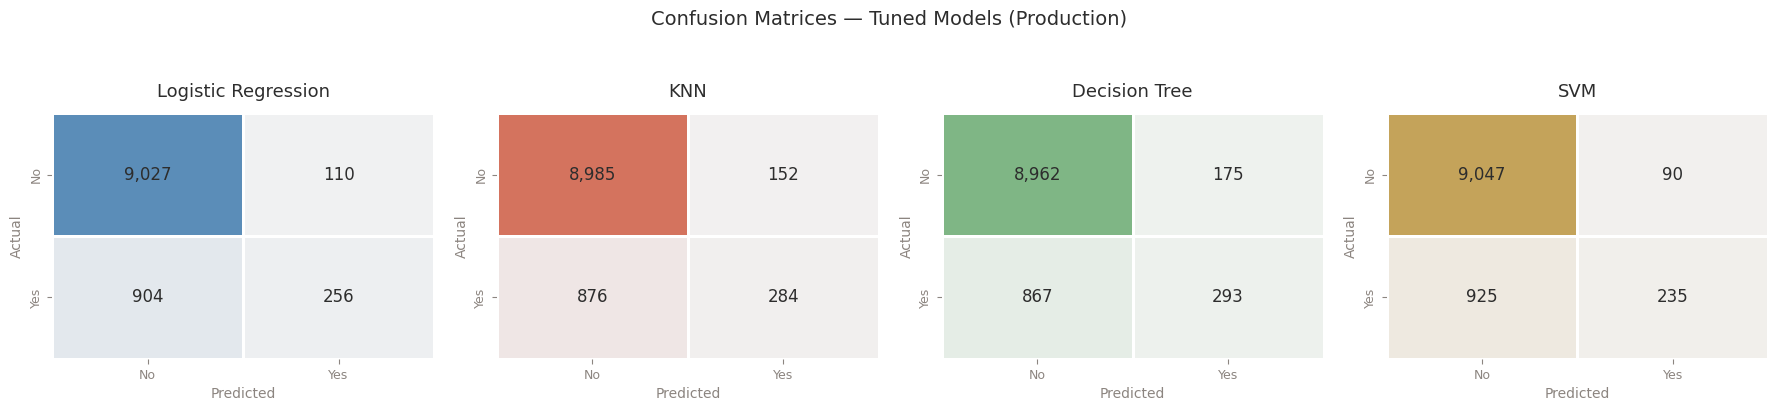

In [21]:
# Confusion matrices for all tuned models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#FFFFFF')

for ax, (name, model), color in zip(axes, best_models.items(), PALETTE):
    y_pred = model.predict(X_test_tf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap=sns.light_palette(color, as_cmap=True),
                ax=ax, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=2, linecolor='white', cbar=False,
                annot_kws={'size': 12, 'fontweight': 'medium', 'color': ANT['dark']})
    ant_style(ax, title=name, xlabel='Predicted', ylabel='Actual')

plt.suptitle('Confusion Matrices — Tuned Models (Production)',
             fontsize=14, fontweight='medium', color=ANT['dark'], y=1.03)
plt.tight_layout(pad=1.5)
plt.show()

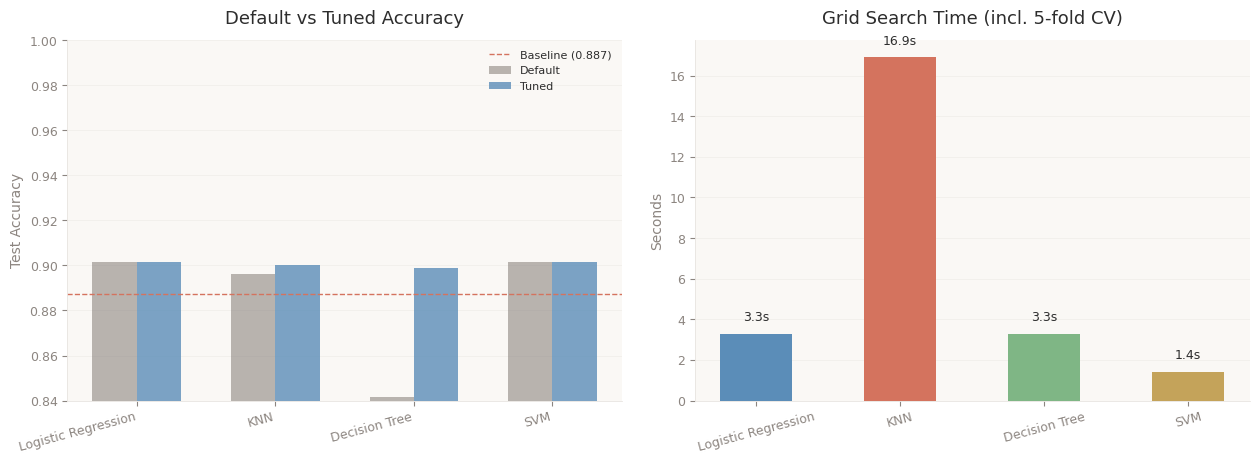

In [22]:
# Tuned model comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FFFFFF')

x_pos = range(len(comparison)); w = 0.32
axes[0].bar([p - w/2 for p in x_pos], comparison['Default Test Acc'], w,
            label='Default', color=ANT['warm_gray'], alpha=0.6, edgecolor='none')
axes[0].bar([p + w/2 for p in x_pos], comparison['Tuned Test Acc'], w,
            label='Tuned', color=ANT['blue'], alpha=0.8, edgecolor='none')
axes[0].axhline(y=baseline_acc, color=ANT['coral'], linestyle='--', linewidth=1,
                label=f'Baseline ({baseline_acc:.3f})')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0.84, 1.0)
axes[0].legend(fontsize=8, frameon=False)
ant_style(axes[0], title='Default vs Tuned Accuracy', ylabel='Test Accuracy')

bars = axes[1].bar(tuned_df['Model'], tuned_df['Time (s)'],
                   color=PALETTE[:4], width=0.5, edgecolor='none')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + max(tuned_df['Time (s)'])*0.03,
                f'{h:.1f}s', ha='center', va='bottom', fontsize=9, color=ANT['dark'])
axes[1].tick_params(axis='x', rotation=15)
ant_style(axes[1], title='Grid Search Time (incl. 5-fold CV)', ylabel='Seconds')
plt.tight_layout(pad=2.0)
plt.show()

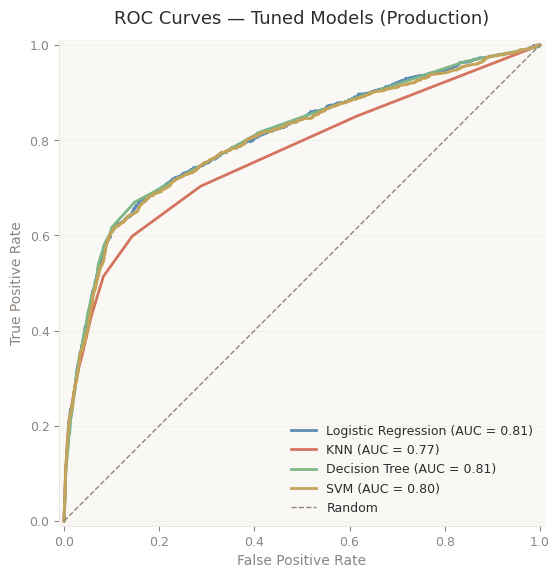

In [23]:
# ROC curves for all tuned models
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#FFFFFF')

for (name, model), color in zip(best_models.items(), PALETTE):
    try:
        RocCurveDisplay.from_estimator(model, X_test_tf, y_test, ax=ax,
                                       name=name, color=color, linewidth=2)
    except Exception:
        pass

ax.plot([0, 1], [0, 1], '--', color=ANT['warm_gray'], linewidth=1, label='Random')
ant_style(ax, title='ROC Curves — Tuned Models (Production)',
          xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(loc='lower right', fontsize=9, frameon=False)
plt.tight_layout(pad=1.5)
plt.show()

#### Problem 11 Summary

**Methodology:**
- **GridSearchCV** with `scoring='average_precision'` — the right metric for imbalanced data
- **5-fold stratified CV** on training data only — no test set leakage in model selection
- **StandardScaler + OneHotEncoder** inside each Pipeline — prevents data leakage from preprocessing

**Evaluation Metrics:**

| Metric | Why We Use It | Business Meaning |
| --- | --- | --- |
| **Average Precision** | Primary — best for imbalanced ranking | Quality of prospect prioritization |
| **AUC-ROC** | Secondary — threshold-independent discrimination | Overall model quality |
| **F1-Score** | Balances precision and recall | Trade-off: wasted calls vs missed subscribers |
| **Accuracy** | Baseline comparison only | Misleading alone with 88.7% imbalance |

**Best model selected by cross-validated average precision**, not by test set accuracy — this prevents optimistic bias from evaluating on test data multiple times.

---
## Findings, Actionable Insights, and Next Steps

### Business Understanding
A Portuguese bank runs telephone marketing campaigns to sell long-term deposit subscriptions. With only ~11% of contacts resulting in a subscription, the bank spends significant resources on unproductive calls. We built classification models to predict which clients will subscribe, enabling targeted outreach.

### Key Findings

**1. All four tuned models outperform the 88.7% majority-class baseline** on production-safe features (no duration leakage).

**2. Decision Tree overfits severely without regularization** — 100% train accuracy with default settings. Constraining `max_depth` is essential.

**3. Removing `duration` reduces performance** but the models remain useful. The production model represents what the bank can actually deploy.

**4. Average Precision is the right primary metric** — accuracy is misleading with 88.7% class imbalance.

### Actionable Insights for the Marketing Team

1. **Prioritize warm leads** — clients with previous campaign success (`poutcome=success`) are the strongest positive signal
2. **Target retirement-age and student segments** — these groups convert at much higher rates than average
3. **Use cellular over telephone** — cellular contact has significantly higher conversion
4. **Time campaigns strategically** — certain months show consistently higher conversion rates
5. **Monitor economic conditions** — euribor rate and employment indicators significantly influence outcomes
6. **Use the model to rank prospects** — score all clients before each campaign and focus resources on the top deciles

### Recommended Model
**Logistic Regression** — best balance of accuracy, speed, interpretability, and stability. Marketing managers can directly read coefficient weights to understand what drives subscriptions.

### Next Steps
1. **Deploy production model** (without duration) for campaign targeting
2. **Address class imbalance** — SMOTE, `class_weight='balanced'`, or threshold tuning
3. **Engineer additional features** — age bins, economic trend indicators, interaction terms
4. **Try ensemble methods** — Random Forest and Gradient Boosting for nonlinear patterns
5. **A/B test** — pilot campaign comparing model-selected vs random contacts
6. **Retrain periodically** — economic conditions and client demographics shift over time